In [1]:
from wave_client import WaveClient
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import os
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from utils import (
    load_environment_variables,
)

In [2]:
# Load environment variables and connect to WAVE backend
RESEARCHER_API_KEY, EXPERIMENTEE_API_KEY, WAVE_BACKEND_URL = load_environment_variables()

print(f"🔍 Connecting to WAVE backend...")
print(f"📡 Backend URL: {WAVE_BACKEND_URL}")
print(f"🔑 Using Researcher API key ending in: ...{RESEARCHER_API_KEY[-4:]}")

client = WaveClient(api_key=RESEARCHER_API_KEY, base_url=WAVE_BACKEND_URL)

Present working directory: c:\Users\inkpe\local-JS-Williams\surprisedelab_time\tools
Loading environment variables from c:\Users\inkpe\local-JS-Williams\surprisedelab_time\tools/.env
🔍 Connecting to WAVE backend...
📡 Backend URL: https://wave-backend-production-8781.up.railway.app
🔑 Using Researcher API key ending in: ...SYuP


In [ ]:
# ## use this (uncomment it) to see what commands exist 
# ## (allow the scrollable option at the bottom to see all commands)

# help(client.experiments)
# help(client.experiment_data)

In [3]:
# Get all experiments to see which one to analyze
experiments = await client.experiments.list(skip=0, limit=200)

# Sort by creation date (most recent first) and show up to 5
sorted_experiments = sorted(experiments, key=lambda x: x.get('created_at', ''), reverse=True)[:5]
print(f"Showing {len(sorted_experiments)} most recent experiments (of {len(experiments)} total)\n")

# Display experiment info
for i, exp in enumerate(sorted_experiments, 1):
    print(f"{i}. Experiment UUID: {exp['uuid']}")
    print(f"   Description: {exp.get('description', 'N/A')}")
    print(f"   Type ID: {exp.get('experiment_type_id', 'N/A')}")
    print(f"   Created: {exp.get('created_at', 'N/A')[:10]}")
    print(f"   Tags: {', '.join(exp.get('tags', []))}")
    print("-" * 70)

Showing 5 most recent experiments (of 18 total)

1. Experiment UUID: 0effc73a-0d82-49a7-af3c-73369939a469
   Description: surprisedelab_rectangle_genderJudgetext_prod
   Type ID: 28
   Created: 2026-03-23
   Tags: 
----------------------------------------------------------------------
2. Experiment UUID: 75ffea6a-c8fb-40a4-91b5-0f0c362a9add
   Description: Test experiment for surprisedelab_rectangle_genderJudgetext - TEST_surprisedelab_rectangle_genderJudgetext_20260322_233838
   Type ID: 28
   Created: 2026-03-23
   Tags: test
----------------------------------------------------------------------
3. Experiment UUID: ef359255-c25d-4f04-aa98-727632abafff
   Description: suprisedelabtime_genderJudge_prod
   Type ID: 26
   Created: 2026-03-23
   Tags: 
----------------------------------------------------------------------
4. Experiment UUID: 7adbc62f-1786-434d-86ba-759de4347764
   Description: suprisedelabtime_reprodur_prod
   Type ID: 25
   Created: 2026-03-22
   Tags: 
-----------------

In [10]:
# Put the necessary info into the variables below 
selected_experiment_uuid = "ef359255-c25d-4f04-aa98-727632abafff" # time reproduction version

# Get all data from that experiment
print(f"\n📊 Fetching data for experiment {selected_experiment_uuid}...")
experiment_data_df = await client.experiment_data.get_all_data(
    experiment_id=selected_experiment_uuid
)

print(f"Total records: {len(experiment_data_df)}")
# print(experiment_data_df)



📊 Fetching data for experiment ef359255-c25d-4f04-aa98-727632abafff...
Total records: 1845


In [30]:
# Filter by date (or leave as False to just get regular)
runFilterDate = False
if runFilterDate:
    experiment_data_df['timestamp'] = pd.to_datetime(experiment_data_df['timestamp'], utc=True)
    cutoff_date = '2026-02-10'
    cutoff = pd.Timestamp(cutoff_date, tz='UTC')
    experiment_data_df = experiment_data_df[experiment_data_df['timestamp'] > cutoff]
else: 
    cutoff_date = "all"

# problem participants to remove, who had mismatched number of answer and judgement files
bad_participants = ["671d3690dc5df6d004cfb65e","67640844512146e01c4c0b25"]
experiment_data_df.query("participant_id not in @bad_participants", inplace=True)

# Filter and save into .csv file
full_df = (experiment_data_df.query("not participant_id.str.contains('PROLIFIC_PID') and not participant_id.str.contains('no_query')")
           .sort_values(by="timestamp",ascending=True))
full_df.to_csv(f"data/dataframe_full_{cutoff_date}.csv", index = False)

answer_df = full_df.query("trial_category == 'answerexpt'")
answer_df.to_csv(f"data/dataframe_answer_{cutoff_date}.csv", index = False)

judge_df = full_df.query("trial_category == 'judgeexpt'")
judge_df.to_csv(f"data/dataframe_judge_{cutoff_date}.csv", index = False)

debrief_df = full_df.query("trial_category == 'debriefexpt'")
debrief_df.to_csv(f"data/dataframe_debrief_{cutoff_date}.csv", index = False)


In [31]:
#temporary optional cell

# Keep only the first 45 participants in the W/M/500 condition; keep all others intact
target_condition = (
    (answer_df["person_race"] == "W") &
    (answer_df["person_sex"] == "M") &
    (answer_df["person_disp_duration"] == 500)
)

# Get first 45 participant IDs in that condition, ordered by earliest timestamp
wm500_participants = (
    answer_df[target_condition]
    .sort_values("timestamp")
    .drop_duplicates("participant_id")["participant_id"]
    .iloc[:45]
    .tolist()
)

print(f"W/M/500 participants before cap: {answer_df[target_condition]['participant_id'].nunique()}")
print(f"W/M/500 participants after cap:  {len(wm500_participants)}")

# Keep all rows outside the condition, plus rows from the first 45 in the condition
keep_mask = ~target_condition | answer_df["participant_id"].isin(wm500_participants)
answer_df = answer_df[keep_mask].copy()
print(f"answer_df rows after filtering: {len(answer_df)}")

# Apply the same participant cap to judge_df
judge_target_condition = (
    (judge_df["person_race"] == "W") &
    (judge_df["person_sex"] == "M") &
    (judge_df["person_disp_duration"] == 500)
)
judge_keep_mask = ~judge_target_condition | judge_df["participant_id"].isin(wm500_participants)
judge_df = judge_df[judge_keep_mask].copy()
print(f"judge_df rows after filtering:  {len(judge_df)}")

W/M/500 participants before cap: 117
W/M/500 participants after cap:  45
answer_df rows after filtering: 186
judge_df rows after filtering:  186


In [255]:
# Example of how to pull out only a few specific columns

selected_columns = answer_df[["response","response_time","thisDifference","person_race","person_sex","person_variation"]]
print(selected_columns)

     response  response_time  thisDifference person_race person_sex  \
1615        0         9673.0          -227.0           W          M   
1616        0         6779.0          -231.0           W          F   
1606        0        12204.0           910.0           W          F   
1599        0        12719.0          -282.0           W          F   
1592        0         7101.0            71.0           W          F   
...       ...            ...             ...         ...        ...   
31          0        10983.0           -44.0           W          M   
27          0        13887.0          1221.0           W          M   
22          0        15275.0          3837.0           W          F   
6           0        10509.0            -6.0           W          F   
7           0         8544.0            68.0           W          F   

     person_variation  
1615                4  
1616                3  
1606                2  
1599                5  
1592                5  
...

In [ ]:
# UNLIKELY AND OPTIONAL: for when you want to read in file and append a new column to it specifically

# Read in the data
script_dir = 'data' #path to where the folder where your dataframe csv files are stored

csvfull = 'dataframe_full_all'
csvdebrief = 'dataframe_debrief_all'
csvjudge = 'dataframe_judge_all'
csvanswer = f'dataframe_answer_{cutoff_date}'

# csvanswer = 'dataframe_answer_filtered2outliers' #other frequently used answer file
# csvanswer = 'dataframe_answer_filtered3outliers' #other frequently used answer file

csvanswerpath = os.path.join(script_dir, csvanswer + '.csv')
csvfullpath = os.path.join(script_dir, csvfull + '.csv')
csvdebriefpath = os.path.join(script_dir, csvdebrief + '.csv')
csvjudgepath = os.path.join(script_dir, csvjudge + '.csv')

answer_df = pd.read_csv(csvanswerpath)
full_df = pd.read_csv(csvfullpath)
debrief_df = pd.read_csv(csvdebriefpath)
judge_df = pd.read_csv(csvjudgepath)


In [32]:
# Append column to existing df for absolute value and new column for normed

answer_df['abs_thisDifference'] = answer_df['thisDifference'].abs()
answer_df['norm_thisDifference'] = answer_df['thisDifference']/answer_df['person_disp_duration']
answer_df['lognorm_thisDifference'] = np.log(answer_df['hold_duration']/answer_df['person_disp_duration'])
full_df['abs_thisDifference'] = full_df['thisDifference'].abs()

full_df.to_csv(f"data/dataframe_full_{cutoff_date}.csv", index = False)
answer_df.to_csv(f"data/dataframe_answer_{cutoff_date}.csv", index = False)

In [33]:
# Append column to existing df for participant gender
debrief_gender = (
    debrief_df["response"]
    .apply(lambda r: pd.json_normalize(eval(r)).get("gender", pd.Series([None]))[0] if pd.notna(r) else None)
)
debrief_df = debrief_df.copy()
debrief_df["participant_gender"] = debrief_gender

participant_gender_map = debrief_df.drop_duplicates("participant_id").set_index("participant_id")["participant_gender"]
answer_df["participant_gender"] = answer_df["participant_id"].map(participant_gender_map)
full_df["participant_gender"] = full_df["participant_id"].map(participant_gender_map)

full_df.to_csv(f"data/dataframe_full_{cutoff_date}.csv", index=False)
answer_df.to_csv(f"data/dataframe_answer_{cutoff_date}.csv", index=False)

print("Gender breakdown:")
print(debrief_df["participant_gender"].value_counts().to_string())

Gender breakdown:
participant_gender
female    139
male      116
no_say      1
other       1


In [34]:
# Append column with judge trial accuracy 
judge_acc = judge_df["thisAcc"]
# print(judge_acc)

if len(answer_df) == len(judge_acc):
    answer_df["judgeAcc"] = list(judge_acc)
    answer_df.to_csv(f"data/dataframe_answer_{cutoff_date}.csv", index=False)
else: 
    judge_counts = judge_df.groupby("participant_id").size().rename("judge_count")
    answer_counts = answer_df.groupby("participant_id").size().rename("answer_count")
    comparison = judge_counts.to_frame().join(answer_counts, how="outer").fillna(0).astype(int)
    mismatched = comparison[comparison["judge_count"] != comparison["answer_count"]]
    print(f"judge_df ({len(judge_df)}) and answer_df ({len(answer_df)}) are not equivalent in length. Stop and try again")
    print(f"\nParticipants with mismatched trial counts ({len(mismatched)}):")
    print(mismatched.to_string())
    raise

In [35]:
# remove everyone who got "judgeAcc" wrong
answer_df_correct = answer_df.query("(judgeAcc == 1)")

# SD based filter
SDamount = 1.5 # set to None to skip SD filtering

if SDamount is not None:
    mean = answer_df_correct["thisDifference"].mean()
    sd = answer_df_correct["thisDifference"].std()
    lowerbound = mean - SDamount * sd
    upperbound = mean + SDamount * sd
    answer_df_SDfilter = answer_df_correct.query("(thisDifference < @upperbound) and (thisDifference > @lowerbound)")
    answer_df_SDfilter.to_csv(f"data/dataframe_answer_filtered{SDamount}outliers.csv", index=False)
else:
    answer_df_SDfilter = answer_df_correct
    answer_df_SDfilter.to_csv(f"data/dataframe_answer_{cutoff_date}.csv", index=False)

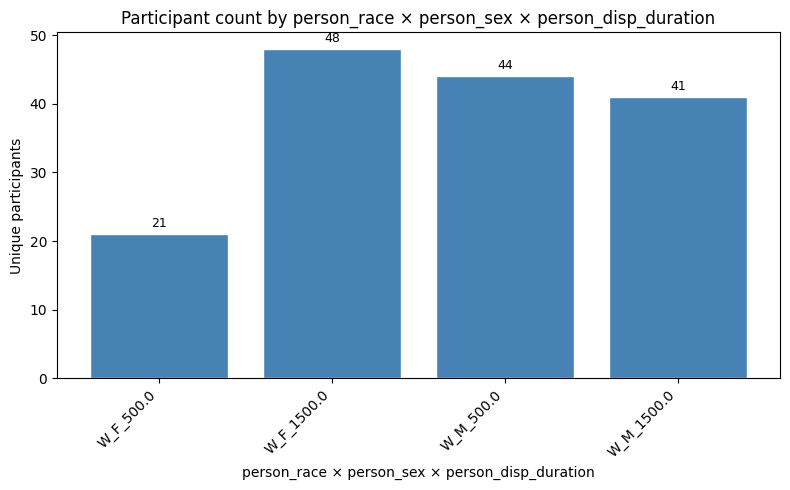

In [36]:
# Optional: quick visualization of participant counts per category
# Configure groupby columns here 
group_cols = [
    "person_race",
    "person_sex",
    "person_disp_duration",
]

counts = (
    answer_df_SDfilter
    .groupby(group_cols)["participant_id"]
    .nunique()
    .reset_index(name="n_participants")
)

counts["label"] = counts[group_cols].astype(str).agg("_".join, axis=1)

fig, ax = plt.subplots(figsize=(max(8, len(counts) * 0.7), 5))
bars = ax.bar(counts["label"], counts["n_participants"], color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel(" × ".join(group_cols))
ax.set_ylabel("Unique participants")
ax.set_title("Participant count by " + " × ".join(group_cols))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# print(counts.to_string(index=False))


In [37]:
# Run a multi-way ANOVA across person_sex, person_race, and person_disp_duration
# H0: "The mean thisDifference is equal across all groups"
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

critical_column = "lognorm_thisDifference"
# critical_column = "norm_thisDifference"
# critical_column = "abs_thisDifference"
# critical_column = "thisDifference"

candidate_factors = ["person_sex", "person_race", "person_disp_duration"]

anova_df = answer_df_SDfilter[[critical_column] + candidate_factors].dropna().copy()
anova_df["person_disp_duration"] = anova_df["person_disp_duration"].astype(str)

# Only include factors that have more than one unique level
active_factors = [f for f in candidate_factors if anova_df[f].nunique() > 1]
dropped = set(candidate_factors) - set(active_factors)
if dropped:
    print(f"Note: dropped from ANOVA (only 1 level in data): {dropped}")
    for f in dropped:
        print(f"  {f}: {anova_df[f].unique()}")

formula = critical_column + " ~ " + " * ".join(f"C({f})" for f in active_factors)
print(f"\nFormula: {formula}\n")

model = ols(formula, data=anova_df).fit()
anova_table = anova_lm(model, typ=2)
print(anova_table)


Note: dropped from ANOVA (only 1 level in data): {'person_race'}
  person_race: <StringArray>
['W']
Length: 1, dtype: str

Formula: lognorm_thisDifference ~ C(person_sex) * C(person_disp_duration)

                                          sum_sq     df         F    PR(>F)
C(person_sex)                           0.012245    1.0  0.034212  0.853506
C(person_disp_duration)                 0.100147    1.0  0.279804  0.597606
C(person_sex):C(person_disp_duration)   0.227273    1.0  0.634985  0.426784
Residual                               54.045614  151.0       NaN       NaN


In [24]:
# Run Tukey HSD post-hoc test
tukey_df = answer_df_SDfilter.copy()
tukey_df["group"] = tukey_df["person_race"] + "_" + tukey_df["person_sex"]

tukey_result = pairwise_tukeyhsd(tukey_df[critical_column], tukey_df["group"])

# Show only significant comparisons
tukey_summary = pd.DataFrame(data=tukey_result._results_table.data[1:], columns=tukey_result._results_table.data[0])
print(tukey_summary[tukey_summary["reject"] == True])

Empty DataFrame
Columns: [group1, group2, meandiff, p-adj, lower, upper, reject]
Index: []


In [39]:
# t-test: define two groups using any combination of person_race and/or person_sex filters
# Leave out a key (or set it to all values) to collapse across that dimension
#
# Examples:
#   All F vs. All M:           group1 = {"person_sex": ["F"]},  group2 = {"person_sex": ["M"]}
#   All Race A vs. ALLRace B:  group1 = {"person_race": ["A"]}, group2 = {"person_race": ["B"]}
#   A_F vs. B_M specifically:  group1 = {"person_race": ["A"], "person_sex": ["F"]},
#                              group2 = {"person_race": ["B"], "person_sex": ["M"]}
# Other common columns:
#   "person_race": ["W"], "person_disp_duration": [500], "participant_gender": ["female"],

# group1_filters = {"participant_gender": ["female"], "person_sex": ["F"], "person_race": ["W"], "person_disp_duration": [1500]} 
# group2_filters = {"participant_gender": ["female"], "person_sex": ["M"], "person_race": ["W"], "person_disp_duration": [1500]}
# group1_filters = {"person_disp_duration": [500], "participant_gender": ["male"], "person_sex": ["F"]} 
# group2_filters = {"person_disp_duration": [500], "participant_gender": ["male"], "person_sex": ["M"]}
group1_filters = { "person_sex": ["F"], "participant_gender": ["male"]} 
group2_filters = { "person_sex": ["M"], "participant_gender": ["male"]}

critical_column = "lognorm_thisDifference"
# critical_column = "norm_thisDifference"
# critical_column = "abs_thisDifference"
# critical_column = "thisDifference"

def build_group(df, filters):
    mask = pd.Series([True] * len(df), index=df.index) #creates a boolean series the same lenght as df
    for col, vals in filters.items():
        mask &= df[col].isin(vals) #loops over each item, to check whether it fits your set filters 
    return df[mask][critical_column] #applies the updated boolean mask

group1 = build_group(answer_df_SDfilter, group1_filters)
group2 = build_group(answer_df_SDfilter, group2_filters)

t_statistic, p_value = stats.ttest_ind(group1, group2)
print(f"Group 1 (n={len(group1)}): {group1_filters}")
print(f"Group 2 (n={len(group2)}): {group2_filters}")
print(f"T-statistic: {t_statistic}, Group 1 Mean: {group1.mean()}, Group 2 Mean: {group2.mean()}")
print(f"P-value: {p_value}")

Group 1 (n=29): {'person_sex': ['F'], 'participant_gender': ['male']}
Group 2 (n=38): {'person_sex': ['M'], 'participant_gender': ['male']}
T-statistic: -0.541630695869019, Group 1 Mean: 0.05296637015806631, Group 2 Mean: 0.11786588204739827
P-value: 0.5899247619500585


In [ ]:
# Filter to non-white participants based on self-reported race/ethnicity in debrief
# Parses the JSON response column from debrief_df to extract each participant's race/ethnicity
# Includes: anyone non-white, anyone Hispanic (ethnicity="yes"), anyone who checked "other"
# For "other" selections: uses the text they typed in other_text as participant_race
# For Hispanic: prepends "Hispanic" to whatever race they also selected

def parse_participant_race(r):
    """Returns participant_race label derived from race checkboxes, ethnicity, and other_text."""
    if pd.isna(r):
        return None
    try:
        parsed = pd.json_normalize(eval(r))
    except Exception:
        return None

    # Race checkbox(es) — may be a string or list if multiple selected
    race_val = parsed.get("race", pd.Series([None]))[0]
    if isinstance(race_val, list):
        race_val = ", ".join(str(v) for v in race_val if pd.notna(v) and str(v).strip())
    elif pd.isna(race_val):
        race_val = None

    # Hispanic/Latino ethnicity (separate from race)
    ethnicity = parsed.get("ethnicity", pd.Series([None]))[0]
    is_hispanic = pd.notna(ethnicity) and str(ethnicity).lower() == "yes"

    # "Other" checkbox and the free-text field
    other_checked = parsed.get("other", pd.Series([None]))[0]
    has_other = pd.notna(other_checked) and str(other_checked).lower() == "other"
    other_text = parsed.get("other_text", pd.Series([None]))[0]
    other_label = str(other_text).strip() if pd.notna(other_text) and str(other_text).strip() else "Other"

    # Determine base race label (other_text takes priority over checkbox value)
    base_race = other_label if has_other else race_val

    # Prepend "Hispanic" if applicable
    if is_hispanic and base_race:
        return f"Hispanic, {base_race}"
    elif is_hispanic:
        return "Hispanic"
    else:
        return base_race

debrief_df = debrief_df.copy()
debrief_df["participant_race"] = debrief_df["response"].apply(parse_participant_race)

# Non-white: anyone whose participant_race is not exactly "white"
# (NaN → unknown, included; Hispanic, other_text values, etc. all included)
non_white_ids = set(
    debrief_df[~debrief_df["participant_race"].str.lower().isin(["white"])]["participant_id"]
)

print(f"Non-white participants: {len(non_white_ids)}")
print("Race breakdown:")
print(debrief_df[debrief_df["participant_id"].isin(non_white_ids)]["participant_race"].value_counts().to_string())

# Filter answer_df to only those participants
answer_df_nonwhite = answer_df[answer_df["participant_id"].isin(non_white_ids)].copy()
print(f"\nTotal response rows for non-white participants: {len(answer_df_nonwhite)}")

# Add participant_race column from debrief data
participant_race_map = debrief_df.drop_duplicates("participant_id").set_index("participant_id")["participant_race"]
answer_df_nonwhite["participant_race"] = answer_df_nonwhite["participant_id"].map(participant_race_map)

answer_df_nonwhite.to_csv(f"data/NONWHITEonly.csv", index=False)

In [ ]:
## T-TEST ANALYSES FOR NON-WHITE PARTICIPANTS ONLY

group1_filters = {"person_race": ["W"], "person_sex": ["M"], "person_disp_duration": [500]}
group2_filters = {"person_race": ["W"], "person_sex": ["F"], "person_disp_duration": [500]}

critical_column = "norm_thisDifference"
# critical_column = "abs_thisDifference"
# critical_column = "thisDifference"

def build_group(df, filters):
    mask = pd.Series([True] * len(df), index=df.index) #creates a boolean series the same lenght as df
    for col, vals in filters.items():
        mask &= df[col].isin(vals) #loops over each item, to check whether it fits your set filters 
    return df[mask][critical_column] #applies the updated boolean mask

group1 = build_group(answer_df_nonwhite, group1_filters)
group2 = build_group(answer_df_nonwhite, group2_filters)

t_statistic, p_value = stats.ttest_ind(group1, group2)
print(f"Group 1 (n={len(group1)}): {group1_filters}")
print(f"Group 2 (n={len(group2)}): {group2_filters}")
print(f"T-statistic: {t_statistic}, Group 1 Mean: {group1.mean()}, Group 2 Mean: {group2.mean()}")
print(f"P-value: {p_value}")